In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

In [3]:
# loading dataset
df = pd.read_csv("../data/Mall_Customers.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [5]:
# <!-- Selecting the features and scalling them -->
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [6]:
# computing the Sillehoutte Scores
silhouette_scores = []
K = range(2, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

    print(f"K={k}, Silhouette Score={score:.4f}")

K=2, Silhouette Score=0.3973
K=3, Silhouette Score=0.4666
K=4, Silhouette Score=0.4943
K=5, Silhouette Score=0.5547
K=6, Silhouette Score=0.5138
K=7, Silhouette Score=0.5020
K=8, Silhouette Score=0.4550
K=9, Silhouette Score=0.4567
K=10, Silhouette Score=0.4448


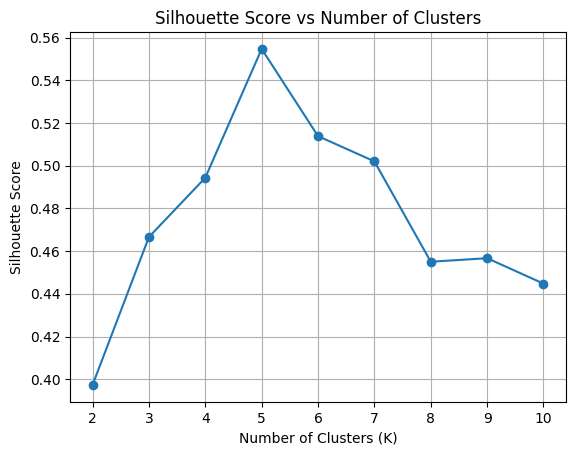

In [7]:
# plotting Silhoutte Score graph
plt.figure()
plt.plot(K, silhouette_scores, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs Number of Clusters")
plt.grid()
plt.show()

TASK  — Compare With Elbow Method
🔹 Step 1 — Compute WCSS (Elbow)

In [8]:
wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

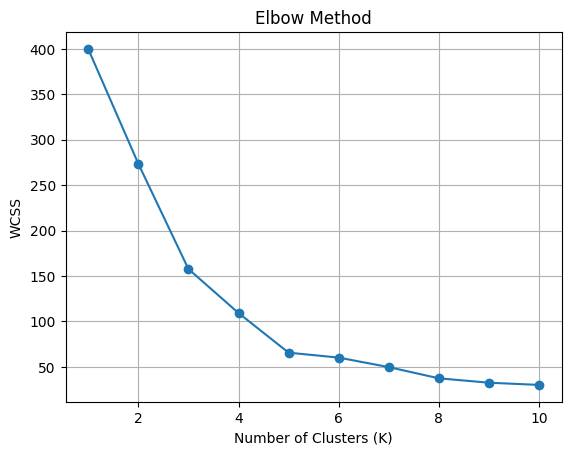

In [9]:
# Step 2 - Plotting the elbow graph
plt.figure()
plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.grid()
plt.show()

# finding the optimal k
Optimal K = Highest Silhouette Score + Elbow bend point = 5